100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:07<00:00, 10.48it/s]


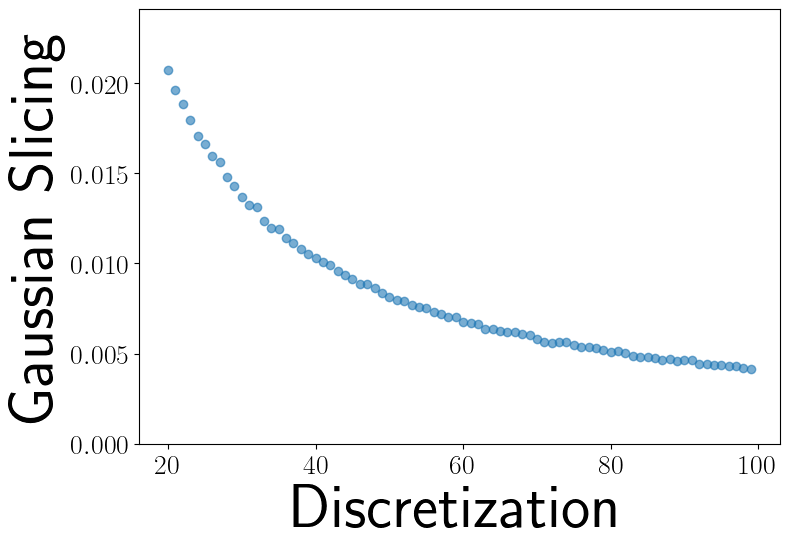

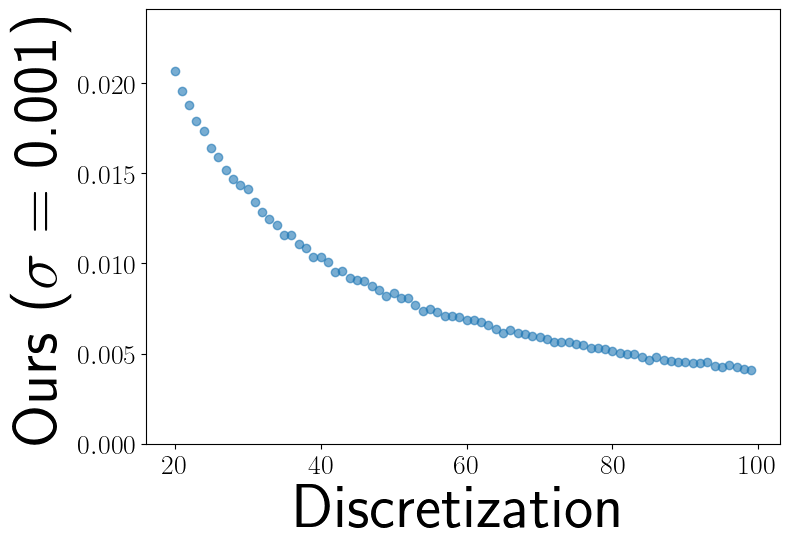

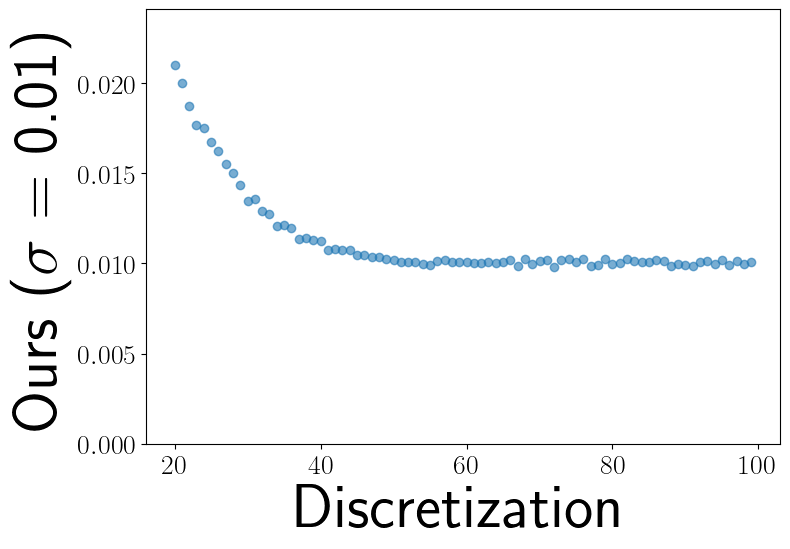

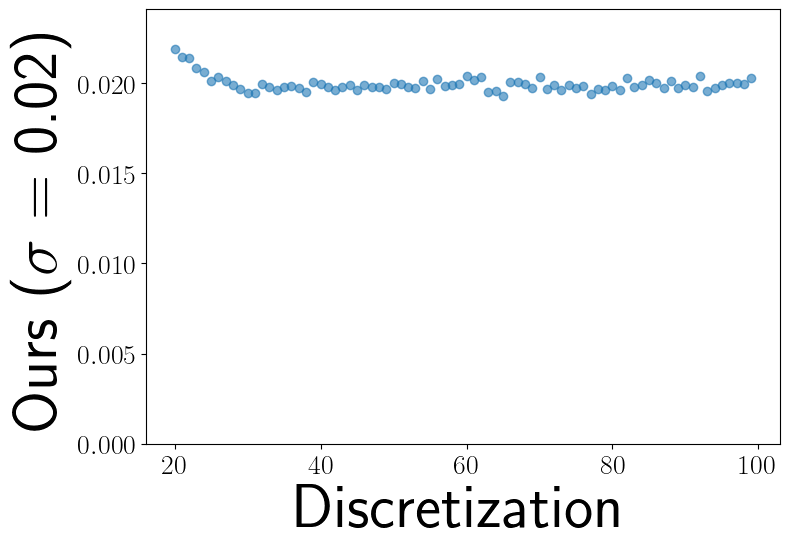

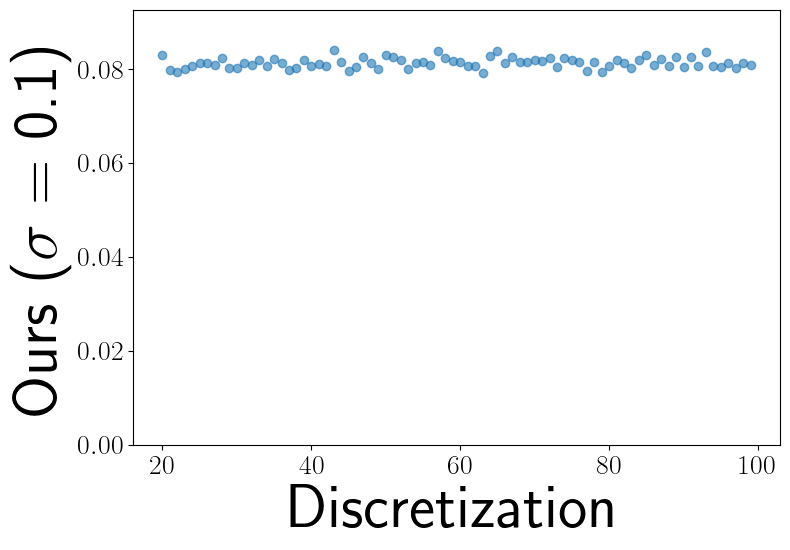

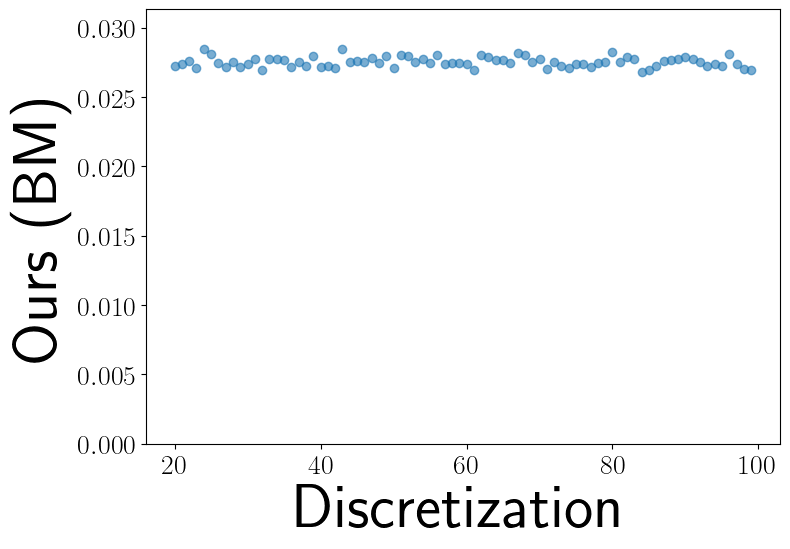

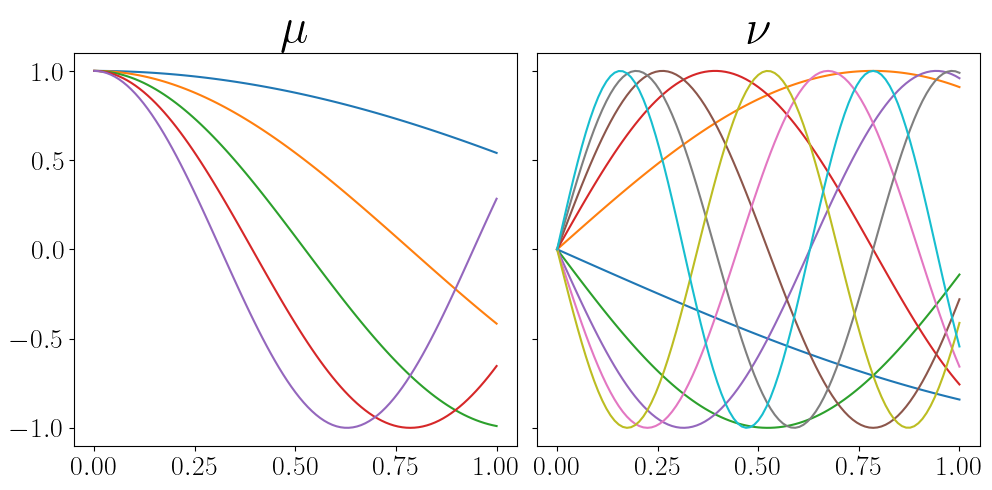

In [7]:
import numpy as np
import copy
from functional_swd import *
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
import seaborn as sns
from scipy import stats
from tqdm import tqdm

def f_tensor(max_num, res):
    lin = torch.linspace(0, 1, res)
    f_ls = [torch.cos((lin*num)).unsqueeze(0) for num in range(1, max_num+1)]
    f_t = torch.concatenate(f_ls)
    return f_t

def g_tensor(max_num, res):
    lin = torch.linspace(0, 1, res)
    g_ls = [torch.sin((lin*num) + num * torch.pi).unsqueeze(0) for num in range(1, max_num+1)]
    g_t = torch.concatenate(g_ls)
    return g_t

def f_tensor_2(max_num, res):
    lin = torch.linspace(0, 1, res)
    f_ls = [(torch.cos((lin*num + num)) + torch.sin(lin)).unsqueeze(0) for num in range(1, max_num+1)]
    f_t = torch.concatenate(f_ls)
    return f_t

def g_tensor_2(max_num, res):
    lin = torch.linspace(0, 1, res)
    g_ls = [(torch.sin(torch.cos(lin))).unsqueeze(0) for num in range(1, max_num+1)]
    g_t = torch.concatenate(g_ls)
    return g_t

def f_tensor_2(max_num, res):
    lin = torch.linspace(0, 1, res)
    f_ls = [(torch.cos((lin*num + num)) + torch.sin(lin)).unsqueeze(0) for num in range(1, max_num+1)]
    f_t = torch.concatenate(f_ls)
    return f_t

def g_tensor_2(max_num, res):
    lin = torch.linspace(0, 1, res)
    g_ls = [(torch.sin(lin * num)**num).unsqueeze(0) for num in range(1, max_num+1)]
    g_t = torch.concatenate(g_ls)
    return g_t

def project_onto_directions(X: torch.Tensor, directions: torch.Tensor) -> torch.Tensor:
    """
    Projects X ∈ (N, D) onto directions ∈ (P, D), returns (P, N).
    """
    X = X.unsqueeze(0)  # (1, N, D)
    directions = directions.unsqueeze(1)  # (P, 1, D)
    return torch.mean(X * directions, dim=2)  # (P, N)

    
def calc_gaussian_SWD(X, Y, n_projections, grid=None, normed=False):
    directions = torch.randn(n_projections, X.shape[-1])
    if normed:
        directions = directions/directions.norm(dim=1).unsqueeze(1)
    X_proj = project_onto_directions(X, directions)  # (P, N)
    Y_proj = project_onto_directions(Y, directions)  # (P, M)
    return estimate_mean_1d_wasserstein2(X_proj, Y_proj)




def plot_scatter(x, y, title, ylim=None):
    # Convert to numpy for scipy/statsmodels
    x_np, y_np = x.numpy(), y.numpy()
    # Make plot
    f, ax = plt.subplots(figsize=(.8*10, .7 *8))
    plt.scatter(x_np, y_np, alpha=.6)
    ax.set_xlabel(r"Discretization", size=45)
    ax.set_ylabel(title, size=45)
    ax.tick_params(labelsize=20)
    if ylim is not None:
        ax.set_ylim(ylim)
    plt.tight_layout()


def estimate_and_plot_l2_slicing(f_tensor_func, g_tensor_func, label="1"):
    dir = "L2_Slicing_Viz/"
    np.random.seed(42)
    torch.manual_seed(42)
    ot_ls = []
    ot_ls2 = []
    ot_ls3 = []
    ot_ls4 = []
    ot_ls_used = []
    ot_ls_r = []
    
    pot_sot_ls_main = []
    res_ls = list(range(20, 100, 1))
    
    for res in tqdm(res_ls):
        f_t = f_tensor_func(5, res).float()
        g_t = g_tensor_func(10, res).float()
        
        
        grid = torch.linspace(0, 1., res)
        ot_dist_1 = calc_functional_SWD_from_discrete_data( g_t, f_t, grid, 
                                                         n_projections=10_000, length_scale=.001)
        ot_dist_2 = calc_functional_SWD_from_discrete_data(g_t, f_t, grid, 
                                                         n_projections=10_000, length_scale=.01)
        ot_dist_3 = calc_functional_SWD_from_discrete_data(g_t, f_t, grid, 
                                                         n_projections=10_000, length_scale=.02)
        ot_dist_4 = calc_functional_SWD_from_discrete_data(g_t, f_t, grid, 
                                                         n_projections=10_000, length_scale=.05)
        ot_dist_used = calc_functional_SWD_from_discrete_data(g_t, f_t, grid, 
                                                 n_projections=10_000, length_scale=.1)
        ot_dist_r = calc_functional_SWD_from_discrete_data(g_t, f_t, grid, 
                                                         n_projections=10_000, length_scale="bm")
        #pot_sot_dist_main = ot.sliced.sliced_wasserstein_distance(g_t/np.sqrt(res), f_t/np.sqrt(res),   n_projections=10_000)
        pot_sot_dist_main = calc_gaussian_SWD(g_t, f_t,   n_projections=10_000, normed=False) #, grid=grid)
        ot_ls.append(ot_dist_1)
        ot_ls2.append(ot_dist_2)
        ot_ls3.append(ot_dist_3)
        ot_ls4.append(ot_dist_4)
        ot_ls_used.append(ot_dist_used)
        ot_ls_r.append(ot_dist_r)
    
        pot_sot_ls_main.append(pot_sot_dist_main)
    
    max_y = 1.1 * np.max([np.max(pot_sot_ls_main), np.max(ot_ls), np.max(ot_ls2), np.max(ot_ls3)])
    _ = plot_scatter(torch.tensor(res_ls), torch.tensor(pot_sot_ls_main), title=r"Gaussian Slicing", ylim=(0., max_y))
    _ = plt.savefig(dir + f"{label}_gaussian_sliced.png")
    _ = plt.show()
    _ = plot_scatter(torch.tensor(res_ls), torch.tensor(ot_ls), title=r"Ours ($\sigma$ = 0.001)", ylim=(0., max_y))
    _ = plt.savefig(dir + f"{label}_0.001_sliced.png")
    _ = plt.show()
    _ = plot_scatter(torch.tensor(res_ls), torch.tensor(ot_ls2), title=r"Ours ($\sigma$ = 0.01)", ylim=(0., max_y))
    _ = plt.savefig(dir + f"{label}_0.01_sliced.png")
    _ = plt.show()
    _ = plot_scatter(torch.tensor(res_ls), torch.tensor(ot_ls3), title=r"Ours ($\sigma$ = 0.02)", ylim=(0., max_y))
    _ = plt.savefig(dir + f"{label}_0.02_sliced.png")
    _ = plt.show()
    
    max_y_used = np.max(ot_ls_used) * 1.1
    _ = plot_scatter(torch.tensor(res_ls), torch.tensor(ot_ls_used), title=r"Ours ($\sigma$ = 0.1)", ylim=(0., max_y_used))
    _ = plt.savefig(dir + f"{label}_used_sliced.png")
    _ = plt.show()
    
    max_y_bm = np.max(ot_ls_r) * 1.1
    _ = plot_scatter(torch.tensor(res_ls), torch.tensor(ot_ls_r), title=r"Ours (BM)", ylim=(0., max_y_bm))
    _ = plt.savefig(dir + f"{label}_sliced_bm.png")
    _ = plt.show()

    f, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
    res_lin = torch.linspace(0, 1, 100)
    _ = ax[0].plot(grid, f_t.transpose(1, 0))
    _ = ax[0].set_title(r"$\mu$", size=35)
    _ = ax[0].tick_params(labelsize=20)
    _ = ax[1].plot(grid, g_t.transpose(1, 0))
    _ = ax[1].set_title(r"$\nu$", size=35)
    _ = ax[1].tick_params(labelsize=20)
    _ = plt.tight_layout()
    _ = plt.savefig(dir + f"{label}_mu_nu_viz.png")
    _ = plt.show()
    
estimate_and_plot_l2_slicing(f_tensor, g_tensor, label="ex1")


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 11.44it/s]


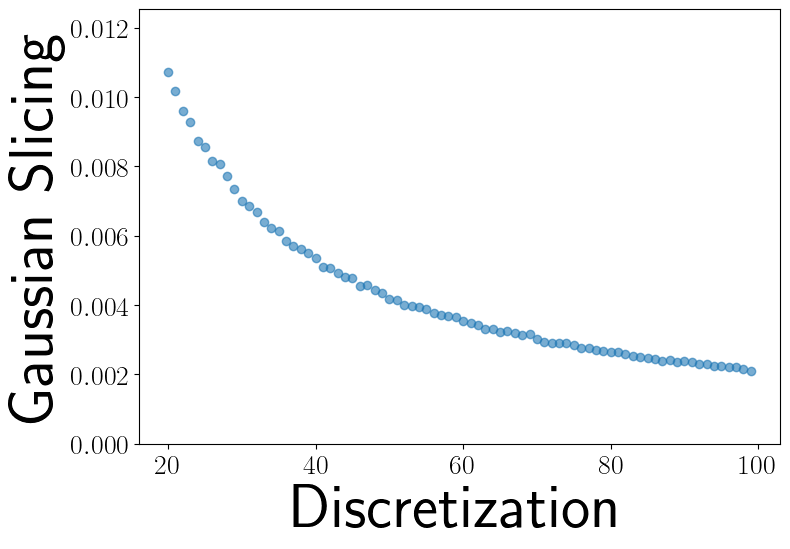

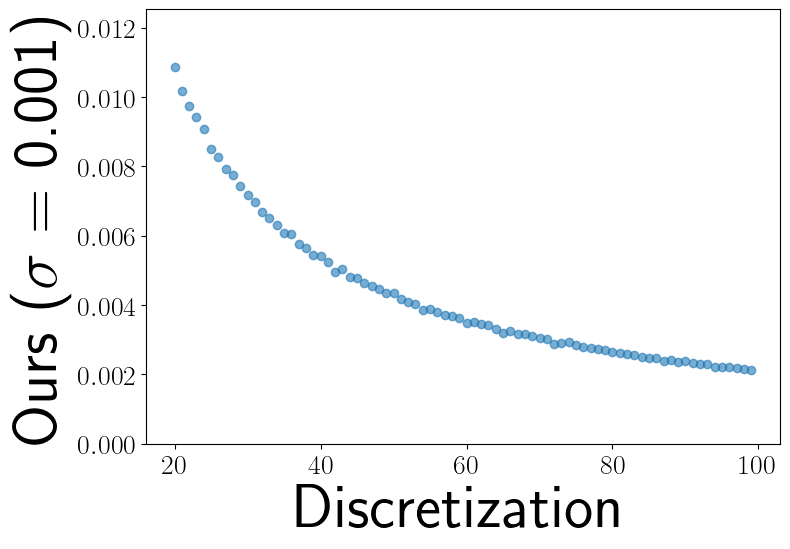

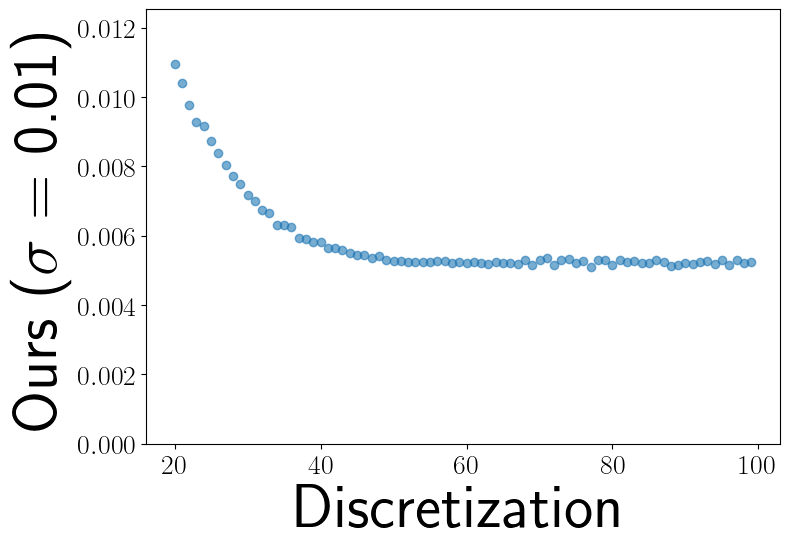

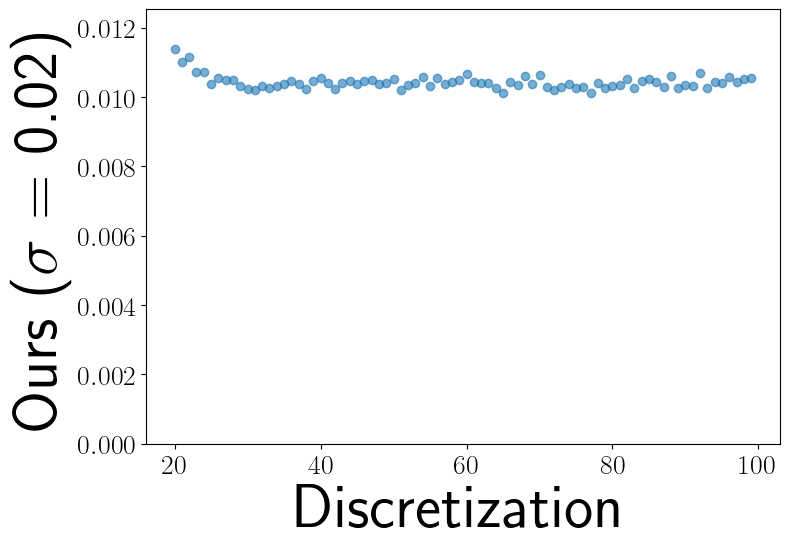

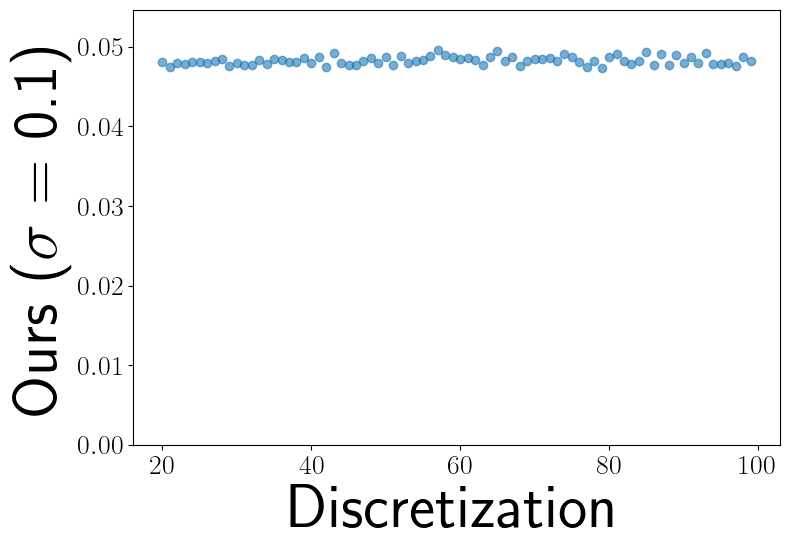

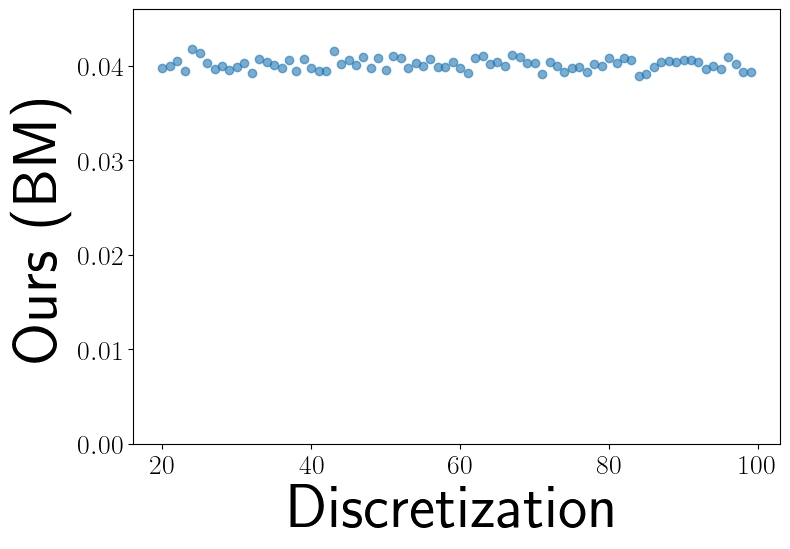

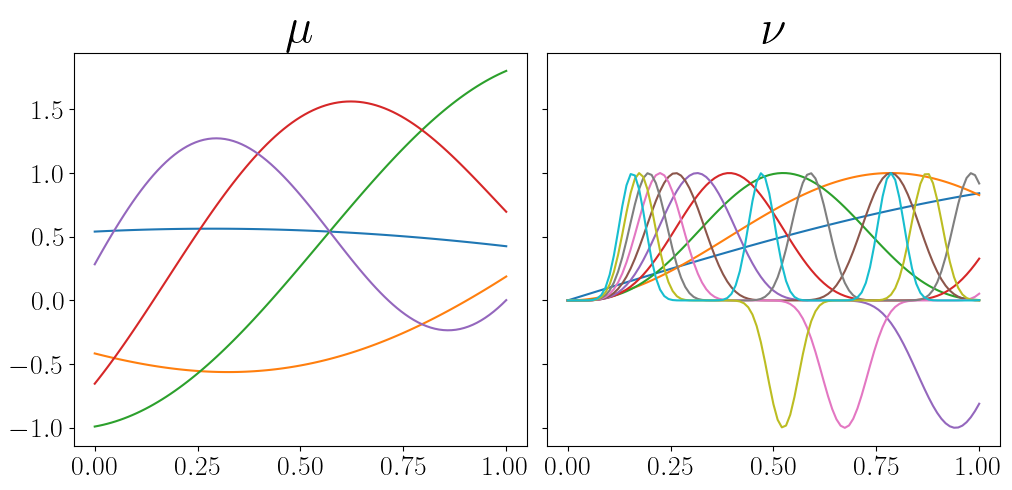

In [8]:
estimate_and_plot_l2_slicing(f_tensor_2, g_tensor_2, label="ex2")